# 핀홀 카메라 모델과 Camera Calibration 실습

> **강의자료**: `강의자료/05.01.OpenCV-Calibration.md`

| Part | 주제 |
|------|------|
| Part 1 | 핀홀 카메라 모델 |
| Part 2 | 카메라 캘리브레이션 실전 |
| Part 3 | 퀴즈 & 복습 문제 |

이 실습에서는 핀홀 카메라 수학 모델을 직접 구현하고,
OpenCV를 사용해 체커보드 기반 카메라 캘리브레이션 전체 파이프라인을 실습합니다.

In [2]:
import numpy as np
import cv2              # pip install opencv-python
import yaml             # pip install pyyaml
import os
import glob
import matplotlib.pyplot as plt

In [3]:
F_MM       = 4.0     # 렌즈 초점 거리 (mm)
DX         = 0.004   # 픽셀 가로 크기 (mm/pixel)
DY         = 0.004   # 픽셀 세로 크기 (mm/pixel)
IMG_WIDTH  = 640     # 이미지 가로 해상도 (pixel)
IMG_HEIGHT = 480     # 이미지 세로 해상도 (pixel)

---
## Part 1: 핀홀 카메라 모델

### 1.1 3D 세계를 2D 이미지로 바꾸는 원리

- **"빛은 직선으로 나아간다"는 단순한 원리로 3D → 2D 변환**
    - **바늘구멍 사진기 (Pinhole Camera)**: 아주 캄캄한 상자 앞면에 바늘구멍 하나를 뚫음
      물체에서 반사된 빛이 구멍을 통과하여 상자 뒷면(센서)에 맺힘
    - **투영 (Projection)**: 3D 공간의 한 점이 구멍을 통과해 2D 평면의 한 점으로 내려앉는 과정
    - **로봇의 거리 추정**: 로봇은 이 원리를 **거꾸로** 이용
      2D 이미지의 한 점 → 실제 3D 공간의 어떤 선상에서 온 것인지 분석
      2D로 변환되는 순간 **'깊이' 정보가 사라짐** → 수학적 모델로 재계산 필요

### 1.2 Aperture (조리개) — 핀홀의 구멍 크기

- **Aperture : 카메라 렌즈에서 빛이 통과하는 구멍의 크기**

| Aperture 크기 | 빛의 양 | 이미지 선명도 |
|---|---|---|
| 크다 (2mm) | 많음  | 흐릿 |
| 작다 (0.35mm) | 적음  | 선명 |

- **핀홀 카메라 모델의 가정**
    - Aperture = **수학적으로 크기가 0인 점**
    - 모든 빛이 딱 한 점을 통과 → 깔끔한 투영 수식 성립
    - 현실에서는 너무 작으면 **빛 부족 → 어두운 이미지** 문제 발생

### 1.3 렌즈 (Lens) — Aperture 딜레마의 해결책

- **핀홀의 딜레마**
  ```
  구멍 크게 → 빛 많음  but  흐릿
  구멍 작게 → 선명     but  어두움
  ```
- **렌즈의 해결책**: 한 점에서 나온 **여러 줄기 빛**을 모아 film의 **한 점으로 수렴**
  ```
  빨간 점 → 여러 빛줄기 → 렌즈 → film의 한 점
  파란 점 → 여러 빛줄기 → 렌즈 → film의 다른 점
  ```
- **새로운 문제**: 렌즈의 굴절 특성 때문에 → **왜곡(Distortion)** 발생
  → 이를 수학적으로 보정하는 것이 **캘리브레이션**

### 1.4 핵심 개념 — 초점 거리 (Focal Length)

- **초점 거리 $f$ : 카메라의 '확대율'을 결정하는 핵심 값**
    - 카메라의 광학 중심(구멍)과 이미지 평면(센서) 사이의 거리
    - 초점 거리가 **길면** → 물체가 크게 보임 (망원)
    - 초점 거리가 **짧으면** → 넓은 범위를 담음 (광각)

- **렌즈 공식**: $\dfrac{1}{f} = \dfrac{1}{z'} - \dfrac{1}{z}$

- **왜 하나의 $f$가 $f_x, f_y$ 두 개가 되는가?** 픽셀이 정사각형이 아닐 수 있기 때문
  $$f_x = \frac{f}{d_x}, \quad f_y = \frac{f}{d_y}$$

| 기호 | 단위 | 의미 |
|---|---|---|
| $f$ | mm | 광학 중심 → 센서 물리적 거리 |
| $d_x, d_y$ | mm/pixel | 픽셀 하나의 실제 크기 |
| $f_x, f_y$ | pixel | 투영 수식의 스케일 인자 |

In [4]:
# 초점 거리: 물리적 단위(mm) → 픽셀 단위 변환
fx = F_MM / DX
fy = F_MM / DY

print(f"물리적 초점 거리 f = {F_MM} mm")
print(f"픽셀 크기 dx={DX} mm/px,  dy={DY} mm/px")
print(f"픽셀 단위 초점 거리  fx = {fx:.1f} px,  fy = {fy:.1f} px")
print(f"  → 'fx = {fx:.0f}' 은 초점 거리가 픽셀 {fx:.0f}개 길이에 해당한다는 의미")

물리적 초점 거리 f = 4.0 mm
픽셀 크기 dx=0.004 mm/px,  dy=0.004 mm/px
픽셀 단위 초점 거리  fx = 1000.0 px,  fy = 1000.0 px
  → 'fx = 1000' 은 초점 거리가 픽셀 1000개 길이에 해당한다는 의미


### 1.5 핵심 개념 — 주점 (Principal Point)

- **주점 $(c_x, c_y)$ : 카메라 렌즈 중심이 이미지와 만나는 기준점**
    - 카메라 렌즈의 중심(광축)이 이미지 센서와 수직으로 만나는 지점의 픽셀 좌표
    - 이상적인 카메라라면 **이미지의 정중앙**이어야 함
    - 실제 제조 과정의 오차로 **조금씩 치우쳐** 있음
    - 이 값이 틀리면 → 로봇이 물체 위치를 잘못 파악

### 1.6 핵심 개념 — 내부 파라미터 행렬 (Camera Matrix K)

**카메라 행렬 $K$ : 카메라의 고유한 '명함'**

초점 거리 $(f_x, f_y)$ 와 주점 $(c_x, c_y)$ 정보를 하나로 묶은 **3×3 행렬**

$$K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$

In [5]:
# 카메라 행렬 K 직접 구성 (예: 640×480 해상도 카메라)
cx = IMG_WIDTH  / 2  # 주점 x (이상적 중앙)
cy = IMG_HEIGHT / 2  # 주점 y (이상적 중앙)

K = np.array([
    [fx,  0,  cx],
    [ 0, fy,  cy],
    [ 0,  0,   1]
], dtype=np.float64)

print("카메라 행렬 K:")
print(K)
print(f"\nfx={K[0,0]}, fy={K[1,1]}, cx={K[0,2]}, cy={K[1,2]}")

카메라 행렬 K:
[[1000.    0.  320.]
 [   0. 1000.  240.]
 [   0.    0.    1.]]

fx=1000.0, fy=1000.0, cx=320.0, cy=240.0


In [6]:
# 카메라 행렬 K로 3D 점 → 2D 픽셀 좌표 투영 (닮음 삼각형 원리)
# 3D 카메라 좌표 (X, Y, Z): Z는 카메라에서 물체까지의 깊이
X, Y, Z = 0.3, 0.1, 2.0    # 단위: m

# 투영 공식: u = fx * X/Z + cx,  v = fy * Y/Z + cy
u = fx * (X / Z) + cx
v = fy * (Y / Z) + cy

print(f"3D 카메라 좌표: ({X}, {Y}, {Z}) m")
print(f"투영된 픽셀 좌표: u={u:.1f}, v={v:.1f}")
print()

3D 카메라 좌표: (0.3, 0.1, 2.0) m
투영된 픽셀 좌표: u=470.0, v=290.0



In [11]:
k = np.array([X/Z, Y/Z, 1])
k

array([0.15, 0.05, 1.  ])

In [12]:
u = K @ k
u

array([470., 290.,   1.])

In [14]:
# 역방향: 픽셀 → 정규화 이미지 좌표 (K^-1 적용, 깊이 Z 필요)
x_norm = (u - cx) / fx    # 정규화 x
y_norm = (v - cy) / fy    # 정규화 y
X_back = x_norm * Z
Y_back = y_norm * Z
print(f"역투영 (Z={Z}m 알고 있을 때): X={X_back}, Y={Y_back}")

역투영 (Z=2.0m 알고 있을 때): X=[ 0.3   -0.06  -0.638], Y=0.1


In [15]:
np.linalg.inv(K) @ u

array([0.15, 0.05, 1.  ])

### 1.7 실제 카메라 vs 수학 모델

- **현실** : 렌즈 카메라 (밝고 선명)
- **수학 모델** : 핀홀 모델 (수식이 단순하고 깔끔)
- **캘리브레이션이 다리 역할**
  ```
  실제 렌즈 카메라
      ↓
  캘리브레이션으로 왜곡 계수(k1, k2, p1, p2, k3) 측정
      ↓
  왜곡 보정 (Rectification)
      ↓
  핀홀 모델 수식 적용
  ```
- 왜곡을 제거하고 나면 → 렌즈 카메라도 **핀홀 카메라처럼 동작**

### 1.8 렌즈 왜곡의 종류

**방사 왜곡 (Radial Distortion)**
- 렌즈 모양 때문에 이미지 **가장자리로 갈수록 직선이 곡선**으로 변하는 현상
- **배럴 왜곡 (Barrel Distortion)**: 이미지가 **볼록하게 튀어나와** 보임 → 광각 렌즈
- **핀쿠션 왜곡 (Pincushion Distortion)**: 이미지가 **오목하게 들어가** 보임 → 망원 렌즈

**접선 왜곡 (Tangential Distortion)**
- 카메라 제조 시 렌즈와 이미지 센서가 **완벽하게 수평을 이루지 못해** 발생
- 이미지가 비스듬하게 기울어져 보이는 현상
- **해결책**: 카메라 캘리브레이션으로 왜곡 계수 측정 후 **직선화(Rectification)**

### 1.9 좌표계의 종류와 변환 흐름

**픽셀 하나를 보고 실제 위치를 알기까지 4단계 좌표 변환**

| 단계 | 좌표계 | 기준 |
|------|--------|------|
| ① | 3D 월드 좌표계 (World Frame) | 방의 구석 등 환경 기준점 |
| ② | 3D 카메라 좌표계 (Camera Frame) | 카메라 렌즈 중심 |
| ③ | 2D 이미지 좌표계 (Image Plane) | 렌즈를 통해 투영된 가상 2D 평면 |
| ④ | 픽셀 좌표계 (Pixel Frame) | 코드에서 다루는 $(u, v)$ 좌표 |

**로봇의 역방향 계산 흐름:**
$$\text{픽셀 좌표} \xrightarrow{K^{-1}} \text{이미지 좌표} \xrightarrow{\text{깊이}} \text{카메라 좌표} \xrightarrow{[R|t]^{-1}} \text{월드 좌표}$$

**닮음 삼각형 원리 (깊이 추정):**
$$\frac{X_{real}}{Z} = \frac{x_{pixel} \times d_x}{f}$$

**혼란 포인트 정리**
- **혼란 1**: 물리적으로 센서에 상이 거꾸로 맺히지만, 수학 모델에서는 이미지 평면을 렌즈 앞에 놓고 똑바로 선 이미지 사용
- **혼란 2**: $K$의 초점 거리는 **픽셀 단위** ($f_x, f_y$) → 미터 단위로 바꾸려면 비례식 필요
- **혼란 3**: 로봇 본체(X=앞, Z=위) vs 카메라 광학 프레임(Z=앞, X=오른쪽, Y=아래) — 축이 90도 다름

In [16]:
# 깊이 추정 예시: 알려진 크기의 물체로 거리 계산
X_real_mm = 100.0   # 물체의 실제 가로 크기 (mm), 예: 10cm 마커
x_pixel   = 50.0    # 이미지에서 물체가 차지하는 픽셀 수

# 닮음 삼각형: X_real / Z = (x_pixel * dx) / f  (단위 mm로 통일 → 결과도 mm)
Z_estimated_mm = X_real_mm * F_MM / (x_pixel * DX)
print(f"물체 실제 크기: {X_real_mm:.0f} mm")
print(f"이미지 픽셀 크기: {x_pixel:.0f} px")
print(f"추정된 거리(깊이): Z ≈ {Z_estimated_mm:.1f} mm  ({Z_estimated_mm/1000:.3f} m)")

물체 실제 크기: 100 mm
이미지 픽셀 크기: 50 px
추정된 거리(깊이): Z ≈ 2000.0 mm  (2.000 m)


---
## Part 2: 카메라 캘리브레이션 실전

### 2.1 캘리브레이션이 필요한 이유

**보정되지 않은 카메라는 직선을 곡선으로 인식하거나 물체 위치를 잘못 파악**

- **캘리브레이션 전**: 직선이 휘어짐, 2D → 3D 정확한 변환 불가
- **캘리브레이션 후**: 왜곡 계수로 이미지 **직선화(Rectification)** 가능,
  픽셀 좌표 ↔ 실제 3D 공간 사이의 **정확한 수학적 관계** 정의

### 2.2 체커보드 패턴 사용 이유

- 명암 대비가 명확 → **내부 교차점(Corners)** 을 서브픽셀 단위로 정밀 감지 가능
- 규칙적인 격자 구조 → 실제 3D 좌표를 쉽게 정의 가능
- **주의**: 칸 수가 아닌 **내부 교차점의 개수**!
- $8 \times 6$ 칸 체커보드 → 내부 교차점은 $7 \times 5$개

### 2.3 올바른 체커보드 촬영 방법

- **장수**: 최소 **10~20장** 권장 (복잡한 왜곡 렌즈는 최대 40장)
- **각도**: 체커보드를 **다양한 축 방향**으로 기울여 촬영 (±15°~45° 범위 권장, 다양한 각도가 초점 거리 계산에 필수)
- **거리**: 카메라와 체커보드 사이의 **거리를 변화**시키며 촬영
- **주의사항**: 체커보드는 **평평하고 단단한 판**에 부착, **줌 수준 일정 유지**,
  이미지 **전체 영역**(특히 가장자리)을 골고루 커버

### 2.4 OpenCV 캘리브레이션 코드 흐름

**OpenCV 캘리브레이션 3단계**

1. **`findChessboardCorners()`**: 이미지에서 체커보드 내부 교차점들의 픽셀 좌표 탐색
2. **`cornerSubPix()`**: 감지된 코너 좌표를 **서브픽셀 단위로 정밀화** → 정확도 향상
3. **`calibrateCamera()`**: 2D 이미지 포인트 + 미리 정의된 3D 객체 포인트를 비교하여
   시스템 방정식을 풀어 **카메라 파라미터 계산**

In [17]:
# 체커보드 설정 (10x7 칸 → 내부 교차점 9x6개)
CHECKERBOARD = (9, 6)       # (가로 교차점 수, 세로 교차점 수)
SQUARE_SIZE  = 0.025        # 체커보드 한 칸의 실제 크기 (m), 예: 2.5cm

# 3D 객체 포인트 준비: (0,0,0), (1,0,0), ..., (8,5,0) 형태로 정의 (Z=0 평면)
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE     # 픽셀 단위가 아닌 실제 크기(m) 적용

print(f"체커보드 설정: {CHECKERBOARD[0]}×{CHECKERBOARD[1]} 내부 교차점")
print(f"총 코너 수: {len(objp)}개")
print(f"첫 번째 코너 3D 좌표: {objp[0]}")
print(f"마지막 코너 3D 좌표: {objp[-1]}")

체커보드 설정: 9×6 내부 교차점
총 코너 수: 54개
첫 번째 코너 3D 좌표: [0. 0. 0.]
마지막 코너 3D 좌표: [0.2   0.125 0.   ]


In [40]:
# 캘리브레이션 전체 파이프라인
# (실제 이미지 파일이 있어야 실행 가능 — 이미지 경로를 수정하세요)

def run_calibration(image_dir: str, pattern=(9, 6), square_size=0.025):
    """체커보드 이미지들로 카메라 캘리브레이션 수행"""
    objp = np.zeros((pattern[0] * pattern[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:pattern[0], 0:pattern[1]].T.reshape(-1, 2)
    objp *= square_size

    objpoints = []   # 3D 실세계 포인트 목록
    imgpoints = []   # 2D 이미지 포인트 목록
    image_size = None

    # cornerSubPix 종료 기준: 정확도(EPS) 또는 최대 반복 횟수(30회) 중 먼저 만족되면 중단
    images = glob.glob(os.path.join(image_dir, '*.jpg')) + \
             glob.glob(os.path.join(image_dir, '*.png'))

    image_paths = []  # 코너 검출 성공한 이미지 경로 목록

    print(f"이미지 {len(images)}장 로드")
    for fname in images:
        img  = cv2.imread(fname)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        image_size = gray.shape[::-1]   # (width, height)

        # ① 체커보드 코너 탐색
        ret, corners = cv2.findChessboardCorners(gray, pattern, None)
        if not ret:
            print(f"  코너 미검출: {os.path.basename(fname)}")
            continue

        # ② 서브픽셀 정밀화
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

        objpoints.append(objp)
        imgpoints.append(corners_refined)
        image_paths.append(fname)
        print(f"  코너 검출 성공: {os.path.basename(fname)}")

    if len(objpoints) < 3:
        print("이미지 부족 (최소 3장 필요). 캘리브레이션 중단.")
        return None, None, None, None, None, None, None, None

    # ③ 캘리브레이션 계산
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
        objpoints, imgpoints, image_size, None, None
    )
    # ret   : 재투영 오차 RMS (픽셀 단위, 1.0 이하면 양호)
    # mtx   : 카메라 행렬 K (3×3) — fx, fy, cx, cy 포함
    # dist  : 왜곡 계수 (k1, k2, p1, p2, k3) — undistort에 사용
    # rvecs : 각 이미지별 회전 벡터 (체커보드 대비 카메라 자세)
    # tvecs : 각 이미지별 이동 벡터 (체커보드 대비 카메라 위치)
    print(f"\n재투영 오차 (RMS Error): {ret:.4f} px")
    print("카메라 행렬 mtx:\n", mtx)
    print("왜곡 계수 dist:", dist.ravel())
    return mtx, dist, ret, rvecs, tvecs, objpoints, imgpoints, image_paths

In [34]:
# 실제 이미지가 있는 경우 아래 주석을 해제하고 경로를 수정하세요
mtx, dist, rms, rvecs, tvecs, objpoints, imgpoints, image_paths = run_calibration("./calib_images/")

이미지 58장 로드
  코너 검출 성공: calib_20260429_113658_815332.jpg
  코너 검출 성공: calib_20260429_113910_370463.jpg
  코너 검출 성공: calib_20260429_113646_772647.jpg
  코너 검출 성공: calib_20260429_113654_821906.jpg
  코너 검출 성공: calib_20260429_113645_772511.jpg
  코너 검출 성공: calib_20260429_113902_589591.jpg
  코너 검출 성공: calib_20260429_113647_477460.jpg
  코너 검출 성공: calib_20260429_113901_124865.jpg
  코너 검출 성공: calib_20260429_113859_058228.jpg
  코너 검출 성공: calib_20260429_113657_186450.jpg
  코너 검출 성공: calib_20260429_113648_901304.jpg
  코너 검출 성공: calib_20260429_113654_020016.jpg
  코너 검출 성공: calib_20260429_113657_681506.jpg
  코너 검출 성공: calib_20260429_113902_820165.jpg
  코너 검출 성공: calib_20260429_113648_302080.jpg
  코너 검출 성공: calib_20260429_113650_463906.jpg
  코너 검출 성공: calib_20260429_113643_883275.jpg
  코너 검출 성공: calib_20260429_113658_115236.jpg
  코너 검출 성공: calib_20260429_113648_501526.jpg
  코너 검출 성공: calib_20260429_113655_282756.jpg
  코너 검출 성공: calib_20260429_113658_615021.jpg
  코너 검출 성공: calib_20260429_113900_022281.jpg

### 2.5 calibrateCamera() 결과 파라미터

```python
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, gray.shape[::-1], None, None
)
```

| 반환값 | 설명 |
|--------|------|
| `ret` | 재투영 오차 (RMS Error) — 작을수록 좋음 |
| `mtx` | 카메라 행렬 $K$ (3×3): $f_x, f_y, c_x, c_y$ 포함 |
| `dist` | 왜곡 계수: 방사 왜곡 $(k_1, k_2, k_3)$ + 접선 왜곡 $(p_1, p_2)$ |
| `rvecs` | 각 이미지의 회전 벡터 (외부 파라미터) |
| `tvecs` | 각 이미지의 이동 벡터 (외부 파라미터) |

### 2.6 품질 평가 — 재투영 오차 (Reprojection Error)

**재투영 오차**: 계산된 카메라 모델로 3D 포인트를 다시 2D에 투영했을 때
실제 감지된 이미지 포인트와의 **거리 차이 (픽셀 단위)**

| RMS Error | 평가 |
|-----------|------|
| 0.5 px 미만 | 산업용 비전 시스템에서 성공적 |
| 1 px 이하  | 대부분의 응용 분야에서 수용 가능 |
| 1 px 초과  | 촬영 데이터 점검 후 재캘리브레이션 필요 |

In [28]:
# 재투영 오차 계산 함수 (캘리브레이션 후 검증용)
def calc_reprojection_error(objpoints, imgpoints, mtx, dist, rvecs, tvecs, image_paths=None):
    """각 이미지별 재투영 오차를 계산하고 평균과 최대 오차 인덱스를 반환"""
    errors = []
    for i, (op, ip) in enumerate(zip(objpoints, imgpoints)):
        # op(z=0 평면의 3D 점)를 rvecs/tvecs로 카메라 좌표계로 변환 후 2D 이미지 평면에 투영
        proj, _ = cv2.projectPoints(op, rvecs[i], tvecs[i], mtx, dist)
        err = cv2.norm(ip, proj, cv2.NORM_L2) / len(proj)
        errors.append(err)
    mean_err = np.mean(errors)
    worst_idx = int(np.argmax(errors))
    print(f"이미지별 재투영 오차: {[f'{e:.4f}' for e in errors]}")
    print(f"평균 재투영 오차: {mean_err:.4f} px")
    if image_paths:
        print(f"최대 오차 이미지: {os.path.basename(image_paths[worst_idx])} ({errors[worst_idx]:.4f} px)")
    return mean_err, worst_idx

In [33]:
_, worst_idx = calc_reprojection_error(objpoints, imgpoints, mtx, dist, rvecs, tvecs, image_paths)

이미지별 재투영 오차: ['0.0772', '0.0560', '0.0620', '0.0834', '0.0380', '0.0710', '0.1044', '0.0497', '0.0476', '0.1371', '0.0488', '0.0269', '0.0465', '0.0985', '0.0567', '0.0910', '0.0262', '0.1082', '0.0420', '0.1160', '0.0522', '0.0458', '0.0290', '0.0819', '0.0827', '0.0201', '0.0511', '0.1251', '0.0245', '0.0517', '0.0291', '0.1071', '0.0471', '0.0720', '0.0790', '0.0609', '0.1020', '0.0449', '0.0330', '0.0578', '0.1082', '0.0818', '0.1812', '0.1200', '0.0794', '0.0453', '0.0622', '0.0471', '0.1492', '0.0510', '0.0650', '0.0477', '0.0487', '0.0468', '0.0382', '0.0855', '0.0453', '0.1275']
평균 재투영 오차: 0.0692 px
최대 오차 이미지: calib_20260429_113659_011864.jpg (0.1812 px)


### 2.7 undistort()로 왜곡 보정하기

In [30]:
# 왜곡 보정 예시 (실제 이미지가 있을 때 실행)
def _line_fitting_residual(img, pattern):
    """체커보드 코너를 검출해 각 행/열을 직선 피팅하고 RMSE 잔차 반환"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, pattern, None)
    if not ret:
        return None
    corners = corners.reshape(pattern[1], pattern[0], 2)  # (행, 열, xy)
    residuals = []
    # 각 행: y ~ ax + b 피팅
    for row in corners:
        x, y = row[:, 0], row[:, 1]        # 한 행의 코너 좌표 (수평으로 나열된 9개 점)
        coeffs = np.polyfit(x, y, 1)       # 최소제곱법으로 y = ax + b의 a, b 계산
        y_pred = np.polyval(coeffs, x)     # 피팅된 직선으로 y 예측
        residuals.append(np.sqrt(np.mean((y - y_pred) ** 2)))
    # 각 열: x ~ ay + b 피팅
    for col in corners.T:
        x, y = col[:, 0], col[:, 1]        # 한 열의 코너 좌표 (수직으로 나열된 6개 점)
        coeffs = np.polyfit(y, x, 1)       # 최소제곱법으로 x = ay + b의 a, b 계산
        x_pred = np.polyval(coeffs, y)     # 피팅된 직선으로 x 예측
        residuals.append(np.sqrt(np.mean((x - x_pred) ** 2)))
    return np.mean(residuals)

In [31]:
def undistort_image(img_path: str, mtx: np.ndarray, dist: np.ndarray, pattern=(9, 6)):
    """캘리브레이션 결과로 이미지 왜곡 보정 및 수치 비교"""
    img = cv2.imread(img_path)
    if img is None:
        print(f"이미지를 불러올 수 없습니다: {img_path}")
        return None

    # 왜곡 보정 적용
    dst = cv2.undistort(img, mtx, dist, None, mtx)

    # 직선 피팅 잔차 비교
    res_before = _line_fitting_residual(img, pattern)
    res_after  = _line_fitting_residual(dst, pattern)
    if res_before and res_after:
        print(f"직선 피팅 잔차 — 보정 전: {res_before:.4f} px  →  보정 후: {res_after:.4f} px  "
              f"(개선율: {(1 - res_after / res_before) * 100:.1f}%)")


    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original (Distorted)")
    axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Undistorted")
    axes[1].axis("off")
    plt.suptitle(os.path.basename(img_path), fontsize=11)
    plt.tight_layout()
    plt.show()
    return dst

직선 피팅 잔차 — 보정 전: 0.3436 px  →  보정 후: 0.2925 px  (개선율: 14.9%)


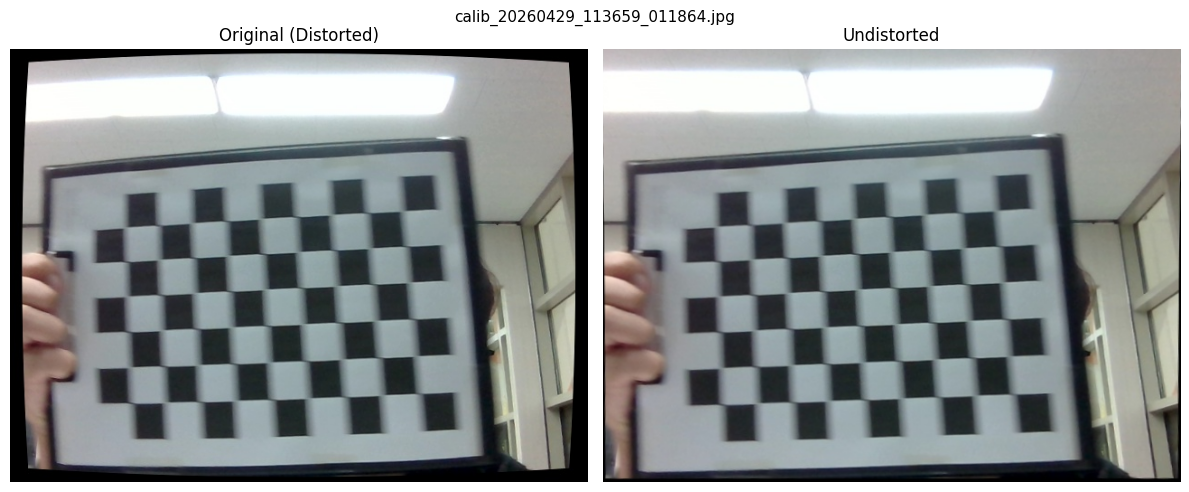

In [32]:
# 재투영 오차가 가장 큰 이미지로 왜곡 보정 전후 비교
dst = undistort_image(image_paths[worst_idx], mtx, dist)

### 2.8 결과 저장 및 불러오기

**캘리브레이션 결과는 매번 계산할 필요 없이 파일로 저장하여 재사용**

In [35]:
# 캘리브레이션 결과 저장 — YAML 형식 (ROS 호환)
def save_calibration_yaml(mtx, dist, filepath="camera_info.yaml"):
    data = {
        'camera_matrix': mtx.tolist(),
        'dist_coeff': dist.tolist()
    }
    with open(filepath, 'w') as f:
        yaml.dump(data, f)
    print(f"YAML 저장 완료: {filepath}")

save_calibration_yaml(mtx, dist)

YAML 저장 완료: camera_info.yaml


In [37]:
# 캘리브레이션 결과 불러오기 — YAML 형식
def load_calibration_yaml(filepath="camera_info.yaml"):
    with open(filepath, 'r') as f:
        data = yaml.safe_load(f)
    mtx  = np.array(data['camera_matrix'], np.float64)
    dist = np.array(data['dist_coeff'], np.float64)
    print(f"YAML 로드 완료: {filepath}")
    print("mtx:\n", mtx)
    print("dist:", dist.ravel())
    return mtx, dist

---
## Part 3: 퀴즈 & 복습 문제

### 연습 문제

/home/gs/Workspace/Robot_project/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


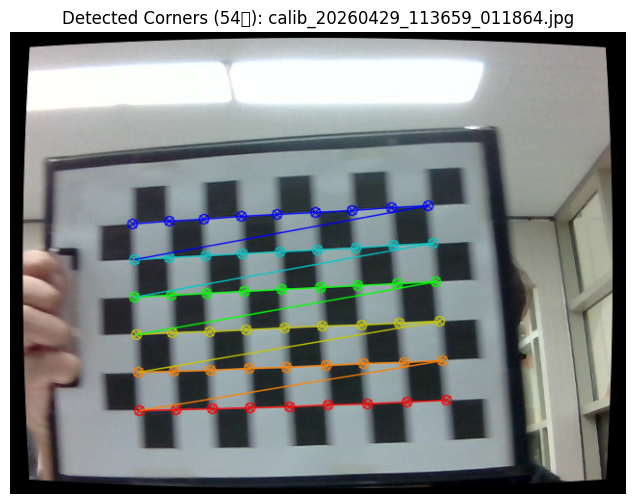

코너 검출 성공: 54개


In [38]:
# TODO: 여기에 구현하세요
# 요구사항: 아래 함수를 완성하세요.
#   - 체커보드 이미지 한 장을 받아 코너를 검출하고 시각화합니다.
#   - 반환값: 서브픽셀 정밀화된 코너 좌표 (검출 실패 시 None)
#
# Hint:
#   - cv2.findChessboardCorners(gray, pattern) → ret, corners
#   - cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria) → corners_refined
#   - cv2.drawChessboardCorners(img, pattern, corners_refined, ret) 로 시각화

def detect_corners(img_path: str, pattern=(9, 6)):
    img = cv2.imread(img_path)
    if img is None:
        print(f"이미지를 불러올 수 없습니다: {img_path}")
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ① 체커보드 코너 탐색
    ret, corners = cv2.findChessboardCorners(gray, pattern, None)
    if not ret:
        print(f"코너 검출 실패: {os.path.basename(img_path)}")
        return None

    # ② 서브픽셀 정밀화
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

    # ③ 시각화
    img_draw = img.copy()
    cv2.drawChessboardCorners(img_draw, pattern, corners_refined, ret)

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected Corners ({len(corners_refined)}개): {os.path.basename(img_path)}")
    plt.axis("off")
    plt.show()

    print(f"코너 검출 성공: {len(corners_refined)}개")
    return corners_refined

corners = detect_corners("calib_images/calib_20260429_113659_011864.jpg")

YAML 로드 완료: camera_info.yaml
mtx:
 [[649.93294354   0.         324.1596311 ]
 [  0.         652.55916042 257.15035489]
 [  0.           0.           1.        ]]
dist: [-0.04659553 -0.6931739   0.0035087  -0.00125148  1.01606274]


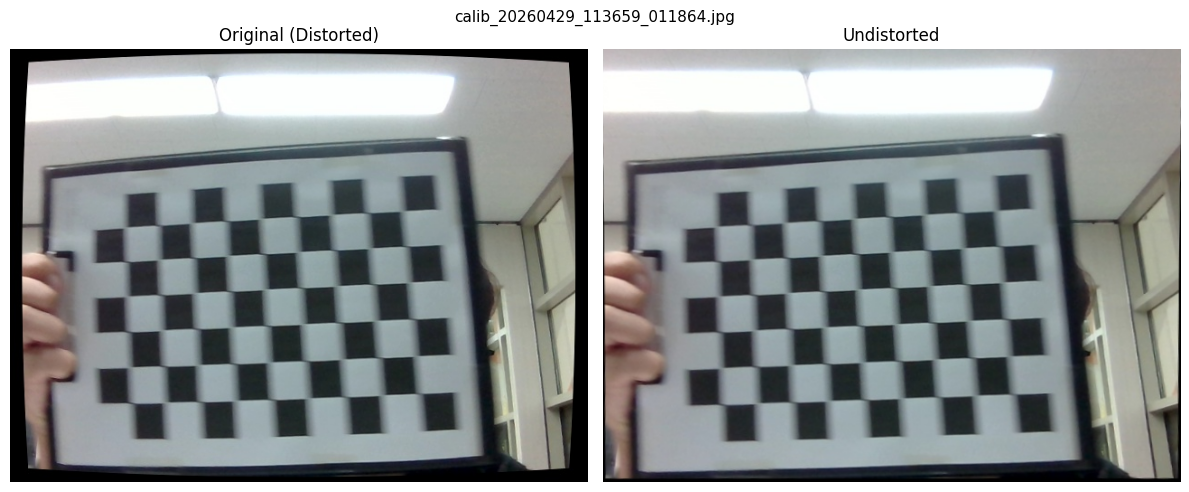

In [39]:
# TODO: 여기에 구현하세요
# 요구사항: 아래 함수를 완성하세요.
#   - 저장된 YAML 파일에서 캘리브레이션 파라미터를 불러와 이미지에 undistort를 적용합니다.
#   - 원본 이미지와 보정된 이미지를 나란히 출력합니다.
#
# Hint:
#   - load_calibration_yaml(yaml_path) 로 mtx, dist 불러오기
#   - cv2.undistort(img, mtx, dist, None, mtx) 로 왜곡 보정
#   - plt.subplots(1, 2) 로 보정 전/후 나란히 표시

def apply_undistort(img_path: str, yaml_path: str):
    # ① YAML에서 캘리브레이션 파라미터 불러오기
    mtx, dist = load_calibration_yaml(yaml_path)

    img = cv2.imread(img_path)
    if img is None:
        print(f"이미지를 불러올 수 없습니다: {img_path}")
        return None

    # ② 왜곡 보정
    dst = cv2.undistort(img, mtx, dist, None, mtx)

    # ③ 보정 전/후 나란히 표시
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original (Distorted)")
    axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Undistorted")
    axes[1].axis("off")
    plt.suptitle(os.path.basename(img_path), fontsize=11)
    plt.tight_layout()
    plt.show()

    return dst

dst = apply_undistort("calib_images/calib_20260429_113659_011864.jpg", "camera_info.yaml")